In [1]:
# Artificial Intelligence PA-DA27
# Final Project:
# Multiclass classification of physiological & pathological ovarian conditions using MLP
# Emilia Cazañas
# May-2026

In [2]:
######################
# MLP - NN Classifier
######################

In [3]:
#---------------------
# 1) Dataset Download
#---------------------
# Environment variable with the specific token and download of the dataset
import os
os.environ['KAGGLE_API_TOKEN'] = "KGAT_0904dd357ae9537346b481e336eb54e6"
!kaggle datasets download -d ucimachinelearning/ovarian-ultrasound-image-dataset

# Unzip the dataset files
import zipfile
ruta_zip = 'ovarian-ultrasound-image-dataset.zip'
with zipfile.ZipFile(ruta_zip, 'r') as zip_ref:
    zip_ref.extractall() # Extract directly in the current directory

print("Dataset:")
total_images = 0
for cat in ["complex_cyst", "dominant_follicle", "healthy", "poly_cyst", "simple_cyst"]:
    n = len(os.listdir(os.path.join("Ovarian_US", cat)))
    print(f"  {cat} - {n} images")
    total_images += n
print(f"Total images: {total_images}")

Dataset URL: https://www.kaggle.com/datasets/ucimachinelearning/ovarian-ultrasound-image-dataset
License(s): CC0-1.0
100% 187M/187M [00:02<00:00, 85.3MB/s]

Dataset:
  complex_cyst - 1368 images
  dominant_follicle - 1297 images
  healthy - 1465 images
  poly_cyst - 1423 images
  simple_cyst - 1326 images
Total images: 6879


In [4]:
#--------------------------------
# 2) Libraries and Initial Setup
#--------------------------------
import os
import cv2
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import warnings
warnings.filterwarnings("ignore")

from PIL import Image
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    roc_curve, auc, precision_recall_fscore_support)
from sklearn.preprocessing import label_binarize

DATA_DIR    = "Ovarian_US"
CATEGORIES  = ["dominant_follicle", "poly_cyst", "complex_cyst", "simple_cyst", "healthy"]
NUM_CLASSES = len(CATEGORIES)
IMG_SIZE    = 64    # MLP input resolution
np.random.seed(42) # Assure Replicability

print("\nLibraries and variables correctly set up ✔")


Libraries and variables correctly set up ✔


Total features (X) shape: (6876, 4096)
Total labels (y) shape: (6876,)


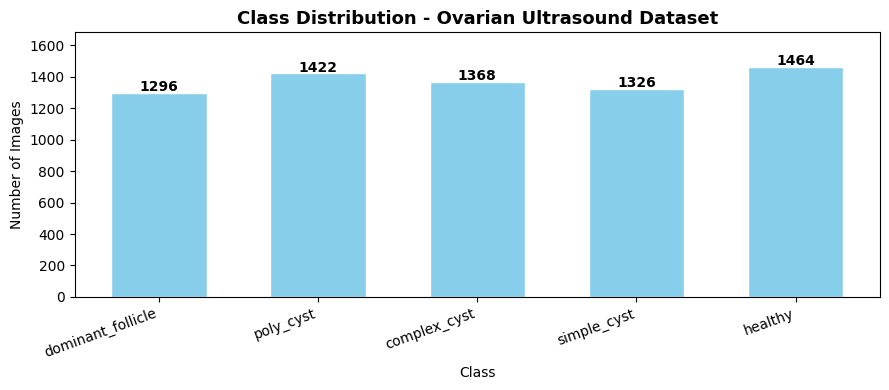

In [5]:
#-----------------------------------
# 3) Data Loading and Preprocessing
#-----------------------------------
def load_and_preprocess_data():
    X_data = []
    y_labels = []

    for category in CATEGORIES:
        path = os.path.join(DATA_DIR, category)
        class_num = CATEGORIES.index(category)

        # Iterate over each image in the category folder
        for img_name in sorted(os.listdir(path)):
            try:
                img_path = os.path.join(path, img_name)
                # Read image in grayscale mode
                img_array = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
                if img_array is None:
                    continue

                # Resize image to 64x64 (IMG_SIZE for MLP)
                resized_array = cv2.resize(img_array, (IMG_SIZE, IMG_SIZE))

                # Flatten the 2D matrix (64x64) into a 1D vector (4096 elements)
                flattened_array = resized_array.flatten()
                X_data.append(flattened_array)
                y_labels.append(class_num)
            except Exception:
                pass # to skip any unreadable files

    # Convert lists to NumPy arrays
    return np.array(X_data), np.array(y_labels, dtype=np.int64)

# Execute the function
X, y = load_and_preprocess_data()

# Normalize the pixel values (0 to 1) for stabilizing the gradients
X = X / 255.0

# Print the dimensions to verify
print(f"Total features (X) shape: {X.shape}")
print(f"Total labels (y) shape: {y.shape}")

# Class distribution plot
fig, ax = plt.subplots(figsize=(9, 4))
counts = [int(np.sum(y == i)) for i in range(NUM_CLASSES)]
bars   = ax.bar(CATEGORIES, counts, color="skyblue", edgecolor="white", width=0.6)

for bar, cnt in zip(bars, counts):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 12,
            str(cnt), ha="center", fontsize=10, fontweight="bold")

ax.set_title("Class Distribution - Ovarian Ultrasound Dataset",
             fontsize=13, fontweight="bold")
ax.set_xlabel("Class"); ax.set_ylabel("Number of Images")
ax.set_ylim(0, max(counts) * 1.15)
plt.xticks(rotation=20, ha="right")
plt.tight_layout()
plt.show()

In [6]:
#-------------------
# 4) Data Splitting
#-------------------
# Stratified 70 / 15 / 15 split on indices
indices = np.arange(len(X))

idx_train, idx_temp = train_test_split(
    indices, test_size=0.30, stratify=y, random_state=42)
idx_val, idx_test = train_test_split(
    idx_temp, test_size=0.50, stratify=y[idx_temp], random_state=42)

y_train_all = y[idx_train]
y_val_all   = y[idx_val]
y_test_all  = y[idx_test]

assert len(set(idx_train) & set(idx_val))  == 0
assert len(set(idx_train) & set(idx_test)) == 0
assert len(set(idx_val)   & set(idx_test)) == 0

print(f"Training features   (X_train) shape: ({len(idx_train)}, 224x224)")
print(f"Validation features (X_val)   shape: ({len(idx_val)}, 224x224)")
print(f"Testing features    (X_test)  shape: ({len(idx_test)}, 224x224)")
print(f"\nSplit (seed=42):  Train {len(idx_train)/len(X)*100:.0f}%  "
      f"Val {len(idx_val)/len(X)*100:.0f}%  Test {len(idx_test)/len(X)*100:.0f}%")
print("\nNo overlap between splits verified. (zero data leakage)")

Training features   (X_train) shape: (4813, 224x224)
Validation features (X_val)   shape: (1031, 224x224)
Testing features    (X_test)  shape: (1032, 224x224)

Split (seed=42):  Train 70%  Val 15%  Test 15%

No overlap between splits verified. (zero data leakage)


In [7]:
#---------------------
# 5) Helper Functions
#---------------------
# Sigmoid activation function for hidden layers
def sigmoid(x):
    x = np.clip(x, -500, 500)
    return 1.0 / (1.0 + np.exp(-x))

# Derivative of the sigmoid function for backpropagation
def sigmoid_derivative(x):
    return sigmoid(x) * (1 - sigmoid(x))

# Softmax activation function for the output layer (multiclass)
def softmax(x):
    exps = np.exp(x - np.max(x, axis=0, keepdims=True))
    return exps / np.sum(exps, axis=0, keepdims=True)

# Convert scalar labels into binary vectors (One-Hot Encoding)
def to_categorical(y, num_classes):
    categorical = np.zeros((len(y), num_classes), dtype=np.float32)
    for i, label in enumerate(y):
        categorical[i, int(label)] = 1.0
    return categorical

print("\nSigmoid and softmax functions correctly stablished ✔")


Sigmoid and softmax functions correctly stablished ✔


In [8]:
#---------------------------------------
# 6) NN Classifier Class (with History)
#---------------------------------------
import numpy as np

class NNClassifier(object):
    def __init__(self, sizes, learning_rate=0.02, batch_size=16, epochs=15):
        self.num_layers    = len(sizes)
        self.sizes         = sizes
        self.learning_rate = learning_rate
        self.batch_size    = batch_size
        self.epochs        = epochs

        # Random weights and bias generation
        self.weights = [np.random.randn(x, y) * np.sqrt(1.0 / y)
                        for (x, y) in zip(sizes[1:], sizes[:-1])]
        self.biases  = [np.random.randn(n, 1) for n in sizes[1:]]

        # Keras-style history dictionary
        self.history = {"acc": [], "val_acc": [], "loss": [], "val_loss": []}

    def getOutput(self, x):
        activation = x
        for i, (b, w) in enumerate(zip(self.biases, self.weights)):
            z = np.dot(w, activation) + b
            activation = softmax(z) if i == len(self.weights) - 1 else sigmoid(z)
        return activation

    def predict(self, X_array):
        predictions = np.zeros(len(X_array), dtype=np.int64)
        for i, sample in enumerate(X_array):
            predictions[i] = int(np.argmax(self.getOutput(sample.reshape(-1, 1))))
        return predictions

    def fit(self, X_fit, y_fit, X_val=None, y_val=None):
        np.random.seed(42)
        y_categorical     = to_categorical(y_fit, self.sizes[-1])
        y_val_categorical = to_categorical(y_val, self.sizes[-1]) if y_val is not None else None

        for epoch in range(self.epochs):
            p         = np.random.permutation(len(X_fit))
            X_shuffled = X_fit[p]
            y_shuffled = y_categorical[p]

            for k in range(0, len(X_fit), self.batch_size):
                self.__update_parameters(X_shuffled[k:k+self.batch_size],
                                         y_shuffled[k:k+self.batch_size])

            # Calculate metrics for Training
            train_loss = sum(
                -np.sum(yt.reshape(-1,1) * np.log(self.getOutput(x.reshape(-1,1)) + 1e-8))
                for x, yt in zip(X_shuffled, y_shuffled)
            ) / len(X_fit)
            train_acc = np.mean(self.predict(X_fit) == y_fit)

            # Calculate metrics for Validation
            val_loss, val_acc = 0.0, 0.0
            if X_val is not None:
                val_loss = sum(
                    -np.sum(yt.reshape(-1,1) * np.log(self.getOutput(x.reshape(-1,1)) + 1e-8))
                    for x, yt in zip(X_val, y_val_categorical)
                ) / len(X_val)
                val_acc = np.mean(self.predict(X_val) == y_val)

            self.history["loss"].append(train_loss)
            self.history["acc"].append(train_acc)
            self.history["val_loss"].append(val_loss)
            self.history["val_acc"].append(val_acc)
            print(f"Epoch {epoch+1}/{self.epochs} - "
                  f"loss: {train_loss:.4f} - acc: {train_acc:.4f} - "
                  f"val_loss: {val_loss:.4f} - val_acc: {val_acc:.4f}")

    def __update_parameters(self, batch_X, batch_y):
        nabla_b = [np.zeros(b.shape) for b in self.biases]
        nabla_w = [np.zeros(w.shape) for w in self.weights]
        for x, y in zip(batch_X, batch_y):
            dnb, dnw = self.__backpropagation(x.reshape(-1,1), y.reshape(-1,1))
            nabla_b  = [nb + dnb_ for nb, dnb_ in zip(nabla_b, dnb)]
            nabla_w  = [nw + dnw_ for nw, dnw_ in zip(nabla_w, dnw)]
        self.weights = [w - (self.learning_rate / len(batch_X)) * nw
                        for w, nw in zip(self.weights, nabla_w)]
        self.biases  = [b - (self.learning_rate / len(batch_X)) * nb
                        for b, nb in zip(self.biases, nabla_b)]

    def __backpropagation(self, x, y):
        nabla_b = [np.zeros(b.shape) for b in self.biases]
        nabla_w = [np.zeros(w.shape) for w in self.weights]
        activation  = x
        activations = [x]
        zs          = []
        for i, (b, w) in enumerate(zip(self.biases, self.weights)):
            z = np.dot(w, activation) + b
            zs.append(z)
            activation = softmax(z) if i == len(self.weights)-1 else sigmoid(z)
            activations.append(activation)
        delta      = activations[-1] - y
        nabla_b[-1] = delta
        nabla_w[-1] = np.dot(delta, activations[-2].T)
        for l in range(2, self.num_layers):
            z      = zs[-l]
            sp     = sigmoid_derivative(z)
            delta  = np.dot(self.weights[-l+1].T, delta) * sp
            nabla_b[-l] = delta
            nabla_w[-l] = np.dot(delta, activations[-l-1].T)
        return nabla_b, nabla_w

print("\nCorrect definition of MLB structure and behavior ✔")


Correct definition of MLB structure and behavior ✔


In [10]:
#------------------------------------
# 7) Model Initialization & Training
#------------------------------------
np.random.seed(42)

# Assign the data to each set
X_train = X[idx_train]
X_val   = X[idx_val]
X_test  = X[idx_test]

# Define architecture dimensions
input_neurons  = X_train.shape[1]
hidden_neurons = 128
output_neurons = len(CATEGORIES)
print(f"Architecture: [{input_neurons}, {hidden_neurons}, {output_neurons}]")

# Instantiate the model
model = NNClassifier(
    sizes=[input_neurons, hidden_neurons, output_neurons],
    learning_rate=0.02,
    batch_size=16,
    epochs=15)

# Start training
model.fit(X_train, y_train_all, X_val=X_val, y_val=y_val_all)

Architecture: [4096, 128, 5]
Epoch 1/15 - loss: 1.0203 - acc: 0.6395 - val_loss: 1.0152 - val_acc: 0.6450
Epoch 2/15 - loss: 0.6995 - acc: 0.7976 - val_loss: 0.6946 - val_acc: 0.7905
Epoch 3/15 - loss: 0.5441 - acc: 0.8645 - val_loss: 0.5435 - val_acc: 0.8526
Epoch 4/15 - loss: 0.4576 - acc: 0.8876 - val_loss: 0.4615 - val_acc: 0.8749
Epoch 5/15 - loss: 0.3790 - acc: 0.9098 - val_loss: 0.3887 - val_acc: 0.8923
Epoch 6/15 - loss: 0.3241 - acc: 0.9254 - val_loss: 0.3383 - val_acc: 0.9069
Epoch 7/15 - loss: 0.2908 - acc: 0.9321 - val_loss: 0.3065 - val_acc: 0.9243
Epoch 8/15 - loss: 0.2506 - acc: 0.9381 - val_loss: 0.2724 - val_acc: 0.9224
Epoch 9/15 - loss: 0.2245 - acc: 0.9462 - val_loss: 0.2506 - val_acc: 0.9292
Epoch 10/15 - loss: 0.2027 - acc: 0.9528 - val_loss: 0.2244 - val_acc: 0.9370
Epoch 11/15 - loss: 0.1806 - acc: 0.9611 - val_loss: 0.2078 - val_acc: 0.9428
Epoch 12/15 - loss: 0.1665 - acc: 0.9630 - val_loss: 0.1903 - val_acc: 0.9525
Epoch 13/15 - loss: 0.1524 - acc: 0.9701 - v


Classification Report:
                   precision    recall  f1-score   support

dominant_follicle       0.98      0.99      0.98       194
        poly_cyst       0.97      1.00      0.98       214
     complex_cyst       0.98      0.98      0.98       205
      simple_cyst       0.97      0.93      0.95       199
          healthy       0.99      0.99      0.99       220

         accuracy                           0.98      1032
        macro avg       0.98      0.98      0.98      1032
     weighted avg       0.98      0.98      0.98      1032



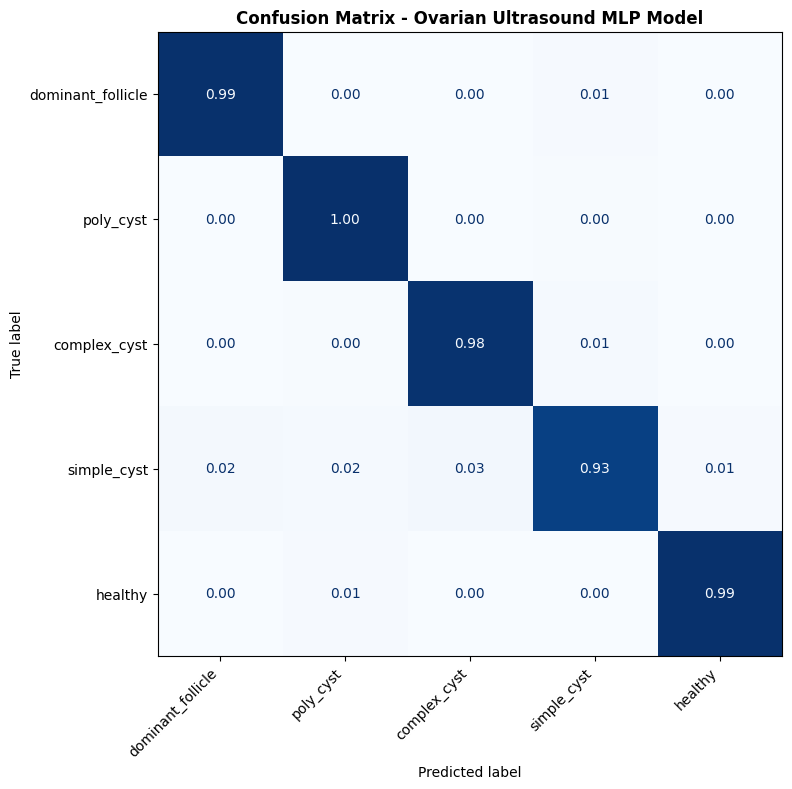

In [11]:
#------------------------
# 8) Evaluation Metrics
#------------------------
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

y_pred = model.predict(X_test)

# Print tabular metrics
print("\nClassification Report:")
print(classification_report(y_test_all, y_pred, target_names=CATEGORIES))

# Normalized confusion matrix
cm      = confusion_matrix(y_test_all, y_pred)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(8, 8))
ConfusionMatrixDisplay(confusion_matrix=cm_norm, display_labels=CATEGORIES).plot(
    ax=ax, cmap=plt.cm.Blues, colorbar=False, values_format=".2f")
ax.set_title("Confusion Matrix - Ovarian Ultrasound MLP Model",
             fontsize=12, fontweight="bold")
plt.xticks(rotation=45, ha="right")
plt.tight_layout(); plt.show()

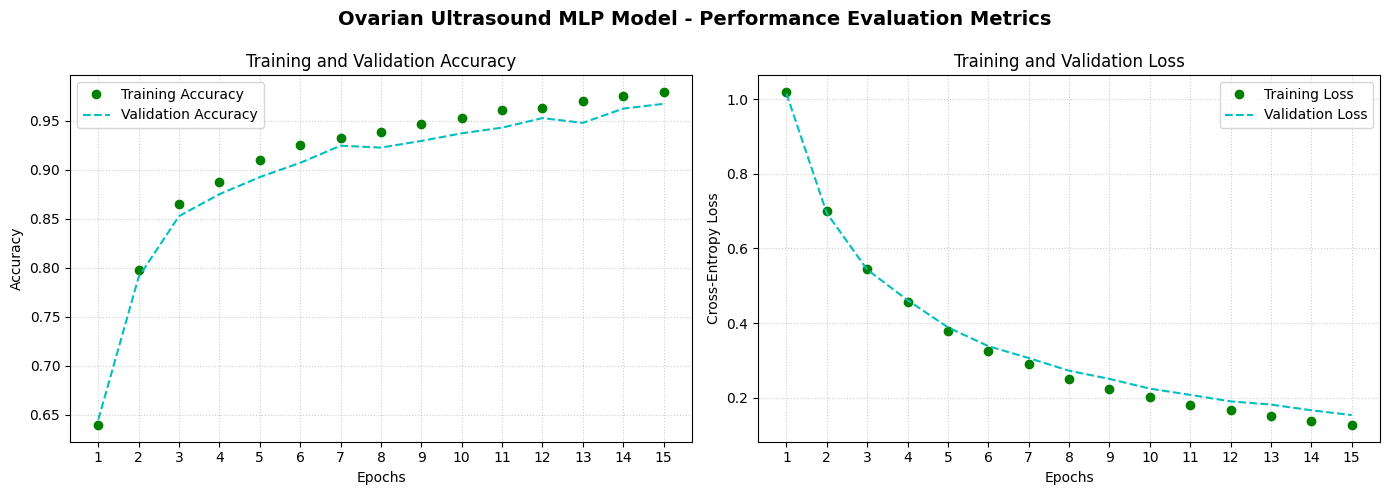

In [12]:
#------------------------------------------
# 9) Plot Training and Validation Metrics
#------------------------------------------
# Retrieve historical metrics from the custom history dictionary
acc      = model.history["acc"]
val_acc  = model.history["val_acc"]
loss     = model.history["loss"]
val_loss = model.history["val_loss"]

epochs = range(1, len(acc) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
plt.suptitle("Ovarian Ultrasound MLP Model - Performance Evaluation Metrics",
             fontsize=14, fontweight="bold")

# A. Plot Training and Validation Accuracy
ax1.plot(epochs, acc,     "go",  label="Training Accuracy")
ax1.plot(epochs, val_acc, "c--", label="Validation Accuracy")
ax1.set_title("Training and Validation Accuracy")
ax1.set_xlabel("Epochs")
ax1.set_ylabel("Accuracy")
ax1.set_xticks(epochs)
ax1.legend()
ax1.grid(True, linestyle=":", alpha=0.6)

# B. Plot Training and Validation Loss
ax2.plot(epochs, loss,     "go",  label="Training Loss")
ax2.plot(epochs, val_loss, "c--", label="Validation Loss")
ax2.set_title("Training and Validation Loss")
ax2.set_xlabel("Epochs")
ax2.set_ylabel("Cross-Entropy Loss")
ax2.set_xticks(epochs)
ax2.legend()
ax2.grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.subplots_adjust(top=0.85)
plt.show()

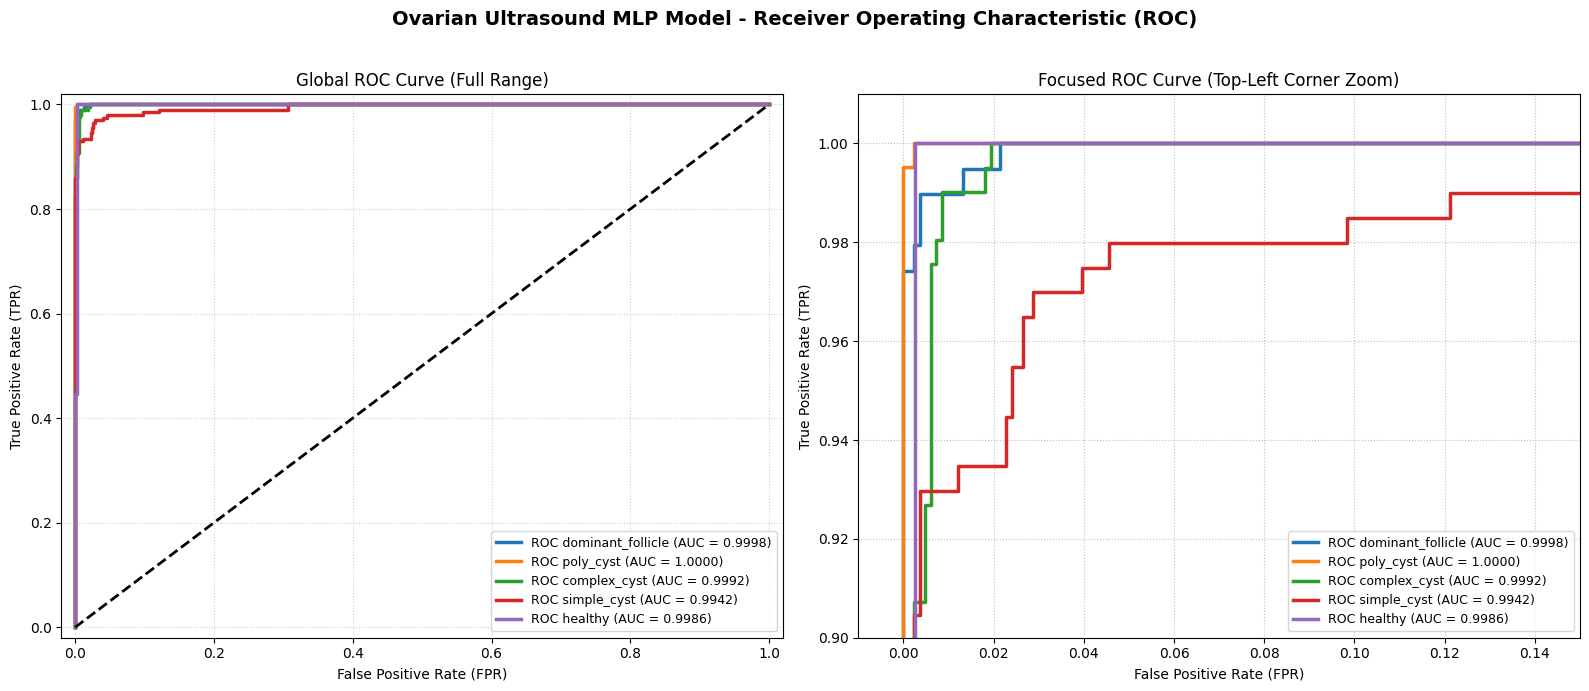

In [13]:
#------------------------------------
# 10) ROC Curve and AUC (Multiclass)
#------------------------------------
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import label_binarize

# Extract probability scores for each class
y_score = np.zeros((len(X_test), len(CATEGORIES)))
for i, sample in enumerate(X_test):
    y_score[i] = model.getOutput(sample.reshape(-1, 1)).flatten()

# Binarize true labels for One-vs-Rest ROC
y_test_bin = label_binarize(y_test_all, classes=range(len(CATEGORIES)))

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
plt.suptitle("Ovarian Ultrasound MLP Model - Receiver Operating Characteristic (ROC)",
             fontsize=14, fontweight="bold")

mlp_auc_scores = {}
for i in range(len(CATEGORIES)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    roc_auc     = auc(fpr, tpr)
    mlp_auc_scores[CATEGORIES[i]] = roc_auc
    label_text = f"ROC {CATEGORIES[i]} (AUC = {roc_auc:.4f})"
    ax1.plot(fpr, tpr, lw=2.5, label=label_text)
    ax2.plot(fpr, tpr, lw=2.5, label=label_text)

# A. Global ROC subplot
ax1.plot([0, 1], [0, 1], color="black", lw=2, linestyle="--")
ax1.set_xlim([-0.02, 1.02]); ax1.set_ylim([-0.02, 1.02])
ax1.set_title("Global ROC Curve (Full Range)")
ax1.set_xlabel("False Positive Rate (FPR)")
ax1.set_ylabel("True Positive Rate (TPR)")
ax1.legend(loc="lower right", fontsize=9)
ax1.grid(True, linestyle=":", alpha=0.6)

# B. Top-Left Corner Zoom ROC subplot
ax2.plot([0, 1], [0, 1], color="black", lw=2, linestyle="--")
ax2.set_xlim([-0.01, 0.15]); ax2.set_ylim([0.90, 1.01])
ax2.set_title("Focused ROC Curve (Top-Left Corner Zoom)")
ax2.set_xlabel("False Positive Rate (FPR)")
ax2.set_ylabel("True Positive Rate (TPR)")
ax2.legend(loc="lower right", fontsize=9)
ax2.grid(True, linestyle=":", alpha=0.8)

plt.tight_layout()
plt.subplots_adjust(top=0.86)
plt.show()

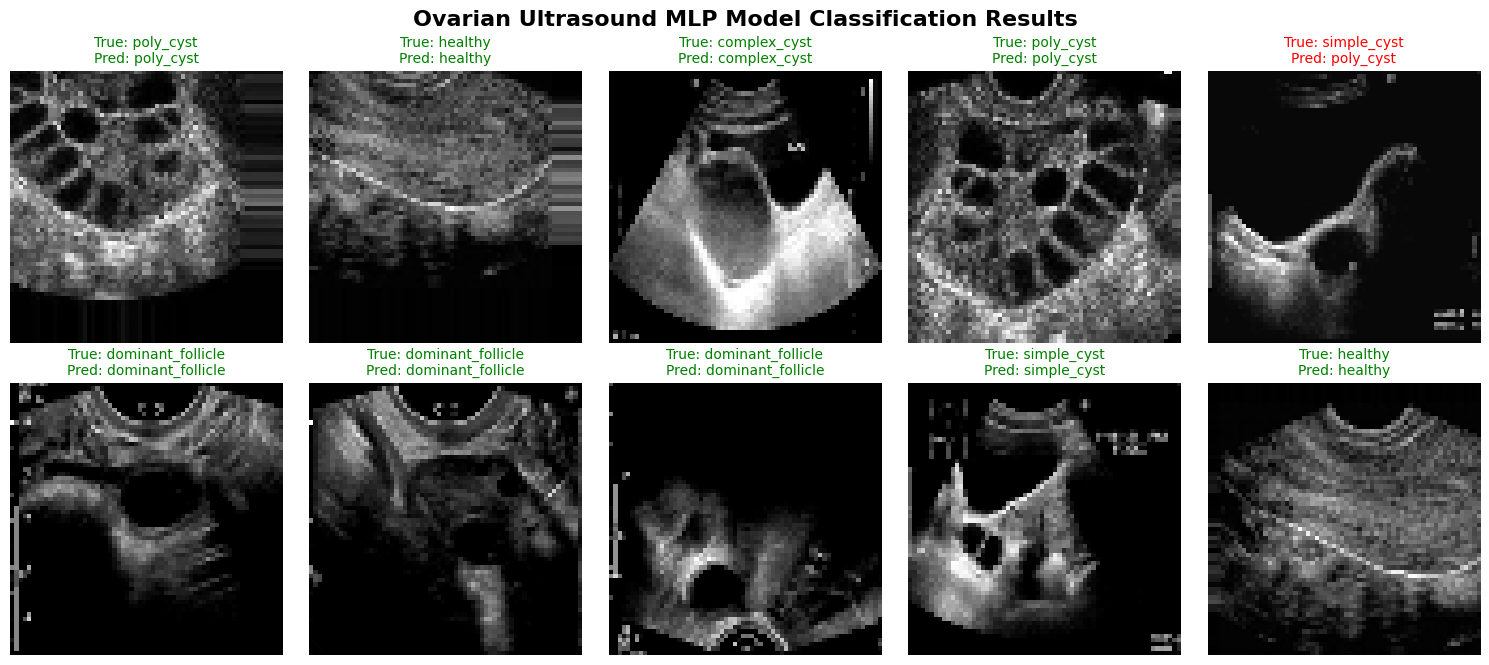

In [24]:
#--------------------------------
# 11) Visual Prediction Examples
#--------------------------------
# We select 10 random images from the test dataset
num_samples    = 10
random_indices = np.random.choice(len(X_test), num_samples, replace=False)

fig, axes = plt.subplots(2, 5, figsize=(15, 7))
fig.suptitle("Ovarian Ultrasound MLP Model Classification Results",
             fontsize=16, fontweight="bold")

for i, ax in enumerate(axes.flatten()):
    idx = random_indices[i]

    # Retrieve the 1D array and reshape it back to 64x64 for visualization
    image_1d = X_test[idx]
    image_2d = image_1d.reshape(64, 64)

    # Map numerical labels back to string categories
    true_label = CATEGORIES[int(y_test_all[idx])]
    pred_label = CATEGORIES[int(y_pred[idx])]

    # Display the image in grayscale
    ax.imshow(image_2d, cmap="gray")
    ax.axis("off")

    # Set title color (Green = correct, Red = incorrect)
    color = "green" if true_label == pred_label else "red"
    ax.set_title(f"True: {true_label}\nPred: {pred_label}", color=color, fontsize=10)

plt.tight_layout()
plt.subplots_adjust(top=0.9, bottom=0.05, hspace=0.1, wspace=0.1)
plt.show()

Upload an ovarian ultrasound image:


Saving dominant_follicle_1020.jpg to dominant_follicle_1020.jpg


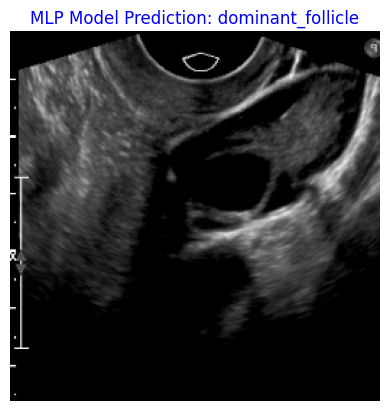

In [19]:
#-----------------------------
# 12) Single Image Prediction
#-----------------------------
import cv2
import numpy as np
import matplotlib.pyplot as plt
from google.colab import files

print("Upload an ovarian ultrasound image:")
uploaded = files.upload()

for file_name in uploaded.keys():
    # Read Raw Image
    img_array = cv2.imread(file_name, cv2.IMREAD_GRAYSCALE)

    # Apply the same preprocessing
    resized_array    = cv2.resize(img_array, (64, 64))
    flattened_array  = resized_array.flatten()
    normalized_array = flattened_array / 255.0
    input_data       = np.array([normalized_array])

    # Predict
    prediction_idx = int(model.predict(input_data)[0])
    pred_label     = CATEGORIES[prediction_idx]

    # Display Result
    plt.imshow(img_array, cmap="gray")
    plt.title(f"MLP Model Prediction: {pred_label}", fontsize=12, color="blue")
    plt.axis("off")
    plt.show()

In [20]:
#---------------------------
# 13) Export Trained Models
#---------------------------
import subprocess, sys
for _pkg in ["timm", "kaggle"]:
    try:
        __import__(_pkg)
    except ImportError:
        print(f"Installing {_pkg}...")
        subprocess.check_call([sys.executable, "-m", "pip", "install", _pkg, "-q"])

import pickle
# Serialize and save the MLP model object to a file
with open("ovarian_mlp_model.pkl", "wb") as file:
    pickle.dump(model, file)
print("MLP model saved  -> ovarian_mlp_model.pkl")


MLP model saved  -> ovarian_mlp_model.pkl


In [25]:
# Streamlit App
# https://ovarian-ultrasound-app-mlp-emv14.streamlit.app/

In [21]:
###########################
# ViT - Vision Transformer
###########################

# Description:
# Fine-tuned vit_small_patch16_224 pretrained on ImageNet-21k
# Staged fine-tuning: head only (5 epochs) → last 4 blocks (up to 15 epochs, early stopping)

In [ ]:
#-------------------------------
# 1- ViT Dataset & DataLoaders
#-------------------------------
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD  = [0.229, 0.224, 0.225]

# Augmentation applied ONLY to the training split
train_tfm = T.Compose([
    T.ToPILImage(),
    T.Grayscale(num_output_channels=3),
    T.RandomHorizontalFlip(p=0.5),
    T.RandomRotation(degrees=15),
    T.ColorJitter(brightness=0.2, contrast=0.2),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])

eval_tfm = T.Compose([
    T.ToPILImage(),
    T.Grayscale(num_output_channels=3),
    T.ToTensor(),
    T.Normalize(mean=IMAGENET_MEAN, std=IMAGENET_STD),
])


class OvarianDataset(Dataset):
    def __init__(self, images, labels, transform=None):
        self.images    = images
        self.labels    = torch.tensor(labels, dtype=torch.long)
        self.transform = transform

    def __len__(self):
        return len(self.images)

    def __getitem__(self, idx):
        img = self.images[idx]
        if self.transform:
            img = self.transform(img)
        return img, self.labels[idx]


_nw  = 4 if device.type == "cuda" else 0
_pin = device.type == "cuda"

train_loader = DataLoader(OvarianDataset(X[idx_train], y[idx_train], train_tfm),
                          batch_size=32, shuffle=True,
                          num_workers=_nw, pin_memory=_pin)
val_loader   = DataLoader(OvarianDataset(X[idx_val],   y[idx_val],   eval_tfm),
                          batch_size=64, shuffle=False,
                          num_workers=_nw, pin_memory=_pin)
test_loader  = DataLoader(OvarianDataset(X[idx_test],  y[idx_test],  eval_tfm),
                          batch_size=64, shuffle=False,
                          num_workers=_nw, pin_memory=_pin)

print(f"DataLoaders ready  (num_workers={_nw}, pin_memory={_pin})")
print(f"  Train batches: {len(train_loader)}  |  "
      f"Val batches: {len(val_loader)}  |  Test batches: {len(test_loader)}")

DataLoaders ready  (num_workers=4, pin_memory=True)
  Train batches: 151  |  Val batches: 17  |  Test batches: 17


In [ ]:
#------------------------------
# 2- ViT Model Initialization
#------------------------------
torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

# vit_small_patch16_224: 22M params, 12 blocks, 6 heads, 384 dim
# Pretrained on ImageNet-21k
vit_model = timm.create_model(
    "vit_small_patch16_224",
    pretrained=True,
    num_classes=NUM_CLASSES,
    drop_rate=0.1,
)
vit_model = vit_model.to(device)

total_params     = sum(p.numel() for p in vit_model.parameters())
trainable_params = sum(p.numel() for p in vit_model.parameters() if p.requires_grad)
print(f"ViT-Small/16 loaded on {device}")
print(f"  Total parameters     : {total_params:,}")
print(f"  Trainable parameters : {trainable_params:,}")

ViT-Small/16 loaded on cuda
  Total parameters     : 21,667,589
  Trainable parameters : 21,667,589


In [ ]:
#------------------------
# 3- ViT Model Training
#------------------------
def run_epoch(model, loader, criterion, optimizer=None, phase="train"):
    model.train() if phase == "train" else model.eval()
    total_loss, correct, total = 0.0, 0, 0
    with torch.set_grad_enabled(phase == "train"):
        for images, labels in loader:
            images = images.to(device, non_blocking=True)
            labels = labels.to(device, non_blocking=True)
            outputs = model(images)
            loss    = criterion(outputs, labels)
            if phase == "train" and optimizer is not None:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * len(labels)
            correct    += (outputs.argmax(1) == labels).sum().item()
            total      += len(labels)
    return total_loss / total, correct / total


vit_history = {"train_loss": [], "train_acc": [],
                "val_loss":   [], "val_acc":   []}
criterion   = nn.CrossEntropyLoss(label_smoothing=0.1)

# ─── Stage 1: Head only (5 epochs) ───────────────────────────────────────────
print("=" * 65)
print("Stage 1 - Training head only  (5 epochs, lr=1e-3)")
print("=" * 65)
for p in vit_model.parameters(): p.requires_grad = False
for p in vit_model.head.parameters(): p.requires_grad = True

opt1 = optim.AdamW(filter(lambda p: p.requires_grad, vit_model.parameters()),
                   lr=1e-3, weight_decay=0.05)
for epoch in range(5):
    tl, ta = run_epoch(vit_model, train_loader, criterion, opt1, "train")
    vl, va = run_epoch(vit_model, val_loader,   criterion, phase="val")
    vit_history["train_loss"].append(tl); vit_history["train_acc"].append(ta)
    vit_history["val_loss"].append(vl);   vit_history["val_acc"].append(va)
    print(f"Epoch {epoch+1}/5 - loss: {tl:.4f} - acc: {ta:.4f} - "
          f"val_loss: {vl:.4f} - val_acc: {va:.4f}")

# ─── Stage 2: Last 4 blocks + head (up to 15 epochs) ─────────────────────────
print("\n" + "=" * 65)
print("Stage 2 - Unfreeze last 4 blocks + head  (up to 15 epochs, lr=2e-5)")
print("=" * 65)
for p in vit_model.parameters(): p.requires_grad = False
for block in vit_model.blocks[-4:]:
    for p in block.parameters(): p.requires_grad = True
for p in vit_model.norm.parameters(): p.requires_grad = True
for p in vit_model.head.parameters(): p.requires_grad = True

opt2      = optim.AdamW(filter(lambda p: p.requires_grad, vit_model.parameters()),
                        lr=2e-5, weight_decay=0.05)
scheduler = optim.lr_scheduler.CosineAnnealingLR(opt2, T_max=15, eta_min=1e-7)
best_val_loss, patience_count, best_state = float("inf"), 0, None
PATIENCE = 5

for epoch in range(15):
    tl, ta = run_epoch(vit_model, train_loader, criterion, opt2, "train")
    vl, va = run_epoch(vit_model, val_loader,   criterion, phase="val")
    scheduler.step()
    vit_history["train_loss"].append(tl); vit_history["train_acc"].append(ta)
    vit_history["val_loss"].append(vl);   vit_history["val_acc"].append(va)
    if vl < best_val_loss - 1e-4:
        best_val_loss  = vl; patience_count = 0
        best_state = {k: v.cpu().clone() for k, v in vit_model.state_dict().items()}
    else:
        patience_count += 1
    print(f"Epoch {epoch+1:2d}/15 - loss: {tl:.4f} - acc: {ta:.4f} - "
          f"val_loss: {vl:.4f} - val_acc: {va:.4f} - "
          f"patience: {patience_count}/{PATIENCE}")
    if patience_count >= PATIENCE:
        print(f"\nEarly stopping at epoch {epoch+1}")
        break

if best_state:
    vit_model.load_state_dict(best_state)
    print(f"\nBest weights restored  (val_loss={best_val_loss:.4f})")

Stage 1 - Training head only  (5 epochs, lr=1e-3)
Epoch 1/5 - loss: 0.7064 - acc: 0.8388 - val_loss: 0.5837 - val_acc: 0.9156
Epoch 2/5 - loss: 0.5646 - acc: 0.9256 - val_loss: 0.5445 - val_acc: 0.9302
Epoch 3/5 - loss: 0.5509 - acc: 0.9296 - val_loss: 0.5353 - val_acc: 0.9331
Epoch 4/5 - loss: 0.5363 - acc: 0.9323 - val_loss: 0.5290 - val_acc: 0.9457
Epoch 5/5 - loss: 0.5313 - acc: 0.9352 - val_loss: 0.5147 - val_acc: 0.9379

Stage 2 - Unfreeze last 4 blocks + head  (up to 15 epochs, lr=2e-5)
Epoch  1/15 - loss: 0.5061 - acc: 0.9545 - val_loss: 0.4732 - val_acc: 0.9670 - patience: 0/5
Epoch  2/15 - loss: 0.4772 - acc: 0.9688 - val_loss: 0.4487 - val_acc: 0.9835 - patience: 0/5
Epoch  3/15 - loss: 0.4535 - acc: 0.9823 - val_loss: 0.4515 - val_acc: 0.9767 - patience: 1/5
Epoch  4/15 - loss: 0.4392 - acc: 0.9890 - val_loss: 0.4334 - val_acc: 0.9913 - patience: 0/5
Epoch  5/15 - loss: 0.4306 - acc: 0.9954 - val_loss: 0.4210 - val_acc: 0.9942 - patience: 0/5
Epoch  6/15 - loss: 0.4264 - ac


Classification Report:
                   precision    recall  f1-score   support

dominant_follicle       1.00      1.00      1.00       194
        poly_cyst       1.00      1.00      1.00       214
     complex_cyst       1.00      1.00      1.00       205
      simple_cyst       1.00      1.00      1.00       199
          healthy       1.00      1.00      1.00       220

         accuracy                           1.00      1032
        macro avg       1.00      1.00      1.00      1032
     weighted avg       1.00      1.00      1.00      1032



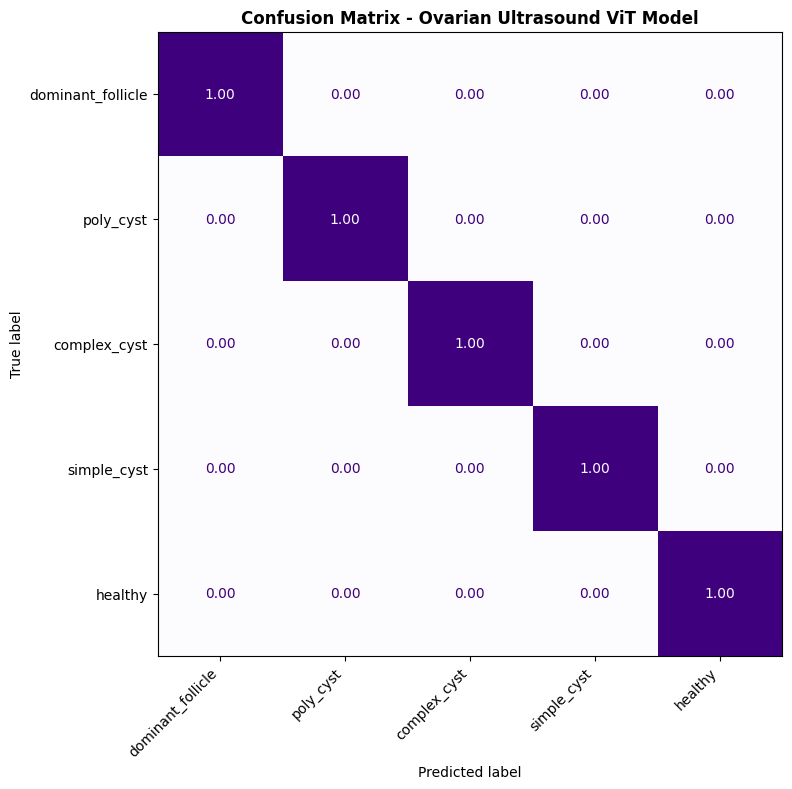

In [ ]:
#----------------------------
# 4- ViT Evaluation Metrics
#----------------------------
vit_model.eval()
_preds, _probs, _labels = [], [], []

with torch.no_grad():
    for images, labels in test_loader:
        images  = images.to(device, non_blocking=True)
        outputs = vit_model(images)
        _preds.append(outputs.argmax(1).cpu())
        _probs.append(torch.softmax(outputs, dim=1).cpu())
        _labels.append(labels.cpu())

y_pred_vit  = torch.cat(_preds).numpy()
y_score_vit = torch.cat(_probs).numpy()

print("\nClassification Report:")
print(classification_report(y_test_all, y_pred_vit, target_names=CATEGORIES))

# Normalized confusion matrix
cm_vit      = confusion_matrix(y_test_all, y_pred_vit)
cm_vit_norm = cm_vit.astype(float) / cm_vit.sum(axis=1, keepdims=True)

fig, ax = plt.subplots(figsize=(8, 8))
ConfusionMatrixDisplay(confusion_matrix=cm_vit_norm, display_labels=CATEGORIES).plot(
    ax=ax, cmap=plt.cm.Purples, colorbar=False, values_format=".2f")
ax.set_title("Confusion Matrix - Ovarian Ultrasound ViT Model",
             fontsize=12, fontweight="bold")
plt.xticks(rotation=45, ha="right")
plt.tight_layout(); plt.show()

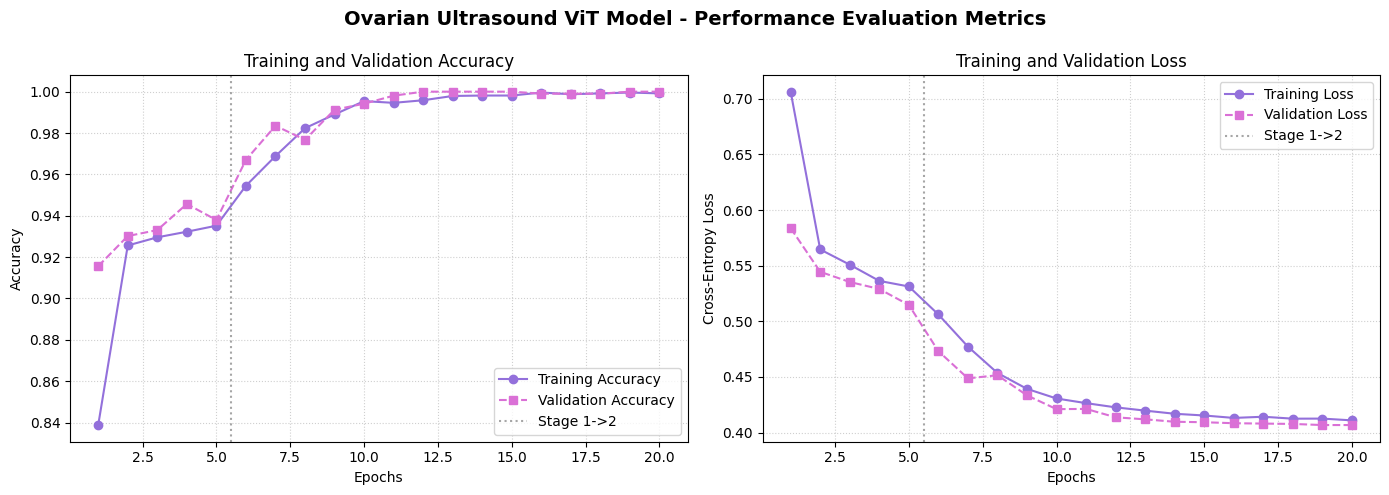

In [ ]:
#------------------------------------------
# 5- Plot Training and Validation Metrics
#------------------------------------------
train_acc = vit_history["train_acc"]
val_acc   = vit_history["val_acc"]
train_loss = vit_history["train_loss"]
val_loss   = vit_history["val_loss"]

epochs_vit = range(1, len(train_acc) + 1)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))
plt.suptitle("Ovarian Ultrasound ViT Model - Performance Evaluation Metrics",
             fontsize=14, fontweight="bold")

# A. Plot Training and Validation Accuracy
ax1.plot(epochs_vit, train_acc, color="mediumpurple", marker="o", label="Training Accuracy")
ax1.plot(epochs_vit, val_acc,   color="orchid", linestyle="--", marker="s",
         label="Validation Accuracy")
ax1.axvline(x=5.5, color="gray", linestyle=":", lw=1.5, alpha=0.7, label="Stage 1->2")
ax1.set_title("Training and Validation Accuracy")
ax1.set_xlabel("Epochs")
ax1.set_ylabel("Accuracy")
ax1.legend()
ax1.grid(True, linestyle=":", alpha=0.6)

# B. Plot Training and Validation Loss
ax2.plot(epochs_vit, train_loss, color="mediumpurple", marker="o", label="Training Loss")
ax2.plot(epochs_vit, val_loss,   color="orchid", linestyle="--", marker="s",
         label="Validation Loss")
ax2.axvline(x=5.5, color="gray", linestyle=":", lw=1.5, alpha=0.7, label="Stage 1->2")
ax2.set_title("Training and Validation Loss")
ax2.set_xlabel("Epochs")
ax2.set_ylabel("Cross-Entropy Loss")
ax2.legend()
ax2.grid(True, linestyle=":", alpha=0.6)

plt.tight_layout()
plt.subplots_adjust(top=0.85)
plt.show()

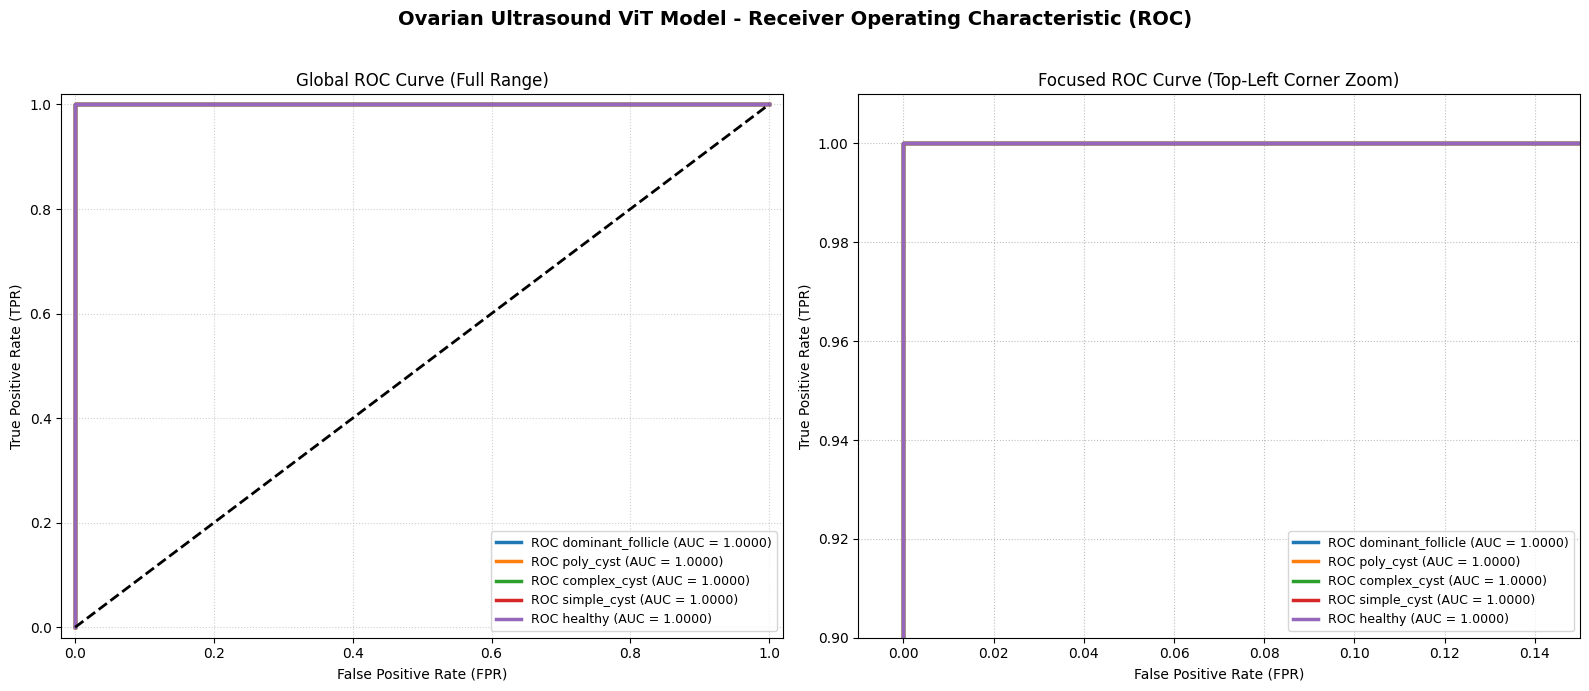

In [ ]:
#------------------------------------
# 6- ROC Curve and AUC (Multiclass)
#------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
plt.suptitle("Ovarian Ultrasound ViT Model - Receiver Operating Characteristic (ROC)",
             fontsize=14, fontweight="bold")

vit_auc_scores = {}
for i in range(len(CATEGORIES)):
    fpr, tpr, _ = roc_curve(y_test_bin[:, i], y_score_vit[:, i])
    roc_auc     = auc(fpr, tpr)
    vit_auc_scores[CATEGORIES[i]] = roc_auc
    label_text = f"ROC {CATEGORIES[i]} (AUC = {roc_auc:.4f})"
    ax1.plot(fpr, tpr, lw=2.5, label=label_text)
    ax2.plot(fpr, tpr, lw=2.5, label=label_text)

ax1.plot([0, 1], [0, 1], color="black", lw=2, linestyle="--")
ax1.set_xlim([-0.02, 1.02]); ax1.set_ylim([-0.02, 1.02])
ax1.set_title("Global ROC Curve (Full Range)")
ax1.set_xlabel("False Positive Rate (FPR)")
ax1.set_ylabel("True Positive Rate (TPR)")
ax1.legend(loc="lower right", fontsize=9)
ax1.grid(True, linestyle=":", alpha=0.6)

ax2.plot([0, 1], [0, 1], color="black", lw=2, linestyle="--")
ax2.set_xlim([-0.01, 0.15]); ax2.set_ylim([0.90, 1.01])
ax2.set_title("Focused ROC Curve (Top-Left Corner Zoom)")
ax2.set_xlabel("False Positive Rate (FPR)")
ax2.set_ylabel("True Positive Rate (TPR)")
ax2.legend(loc="lower right", fontsize=9)
ax2.grid(True, linestyle=":", alpha=0.8)

plt.tight_layout()
plt.subplots_adjust(top=0.86)
plt.show()

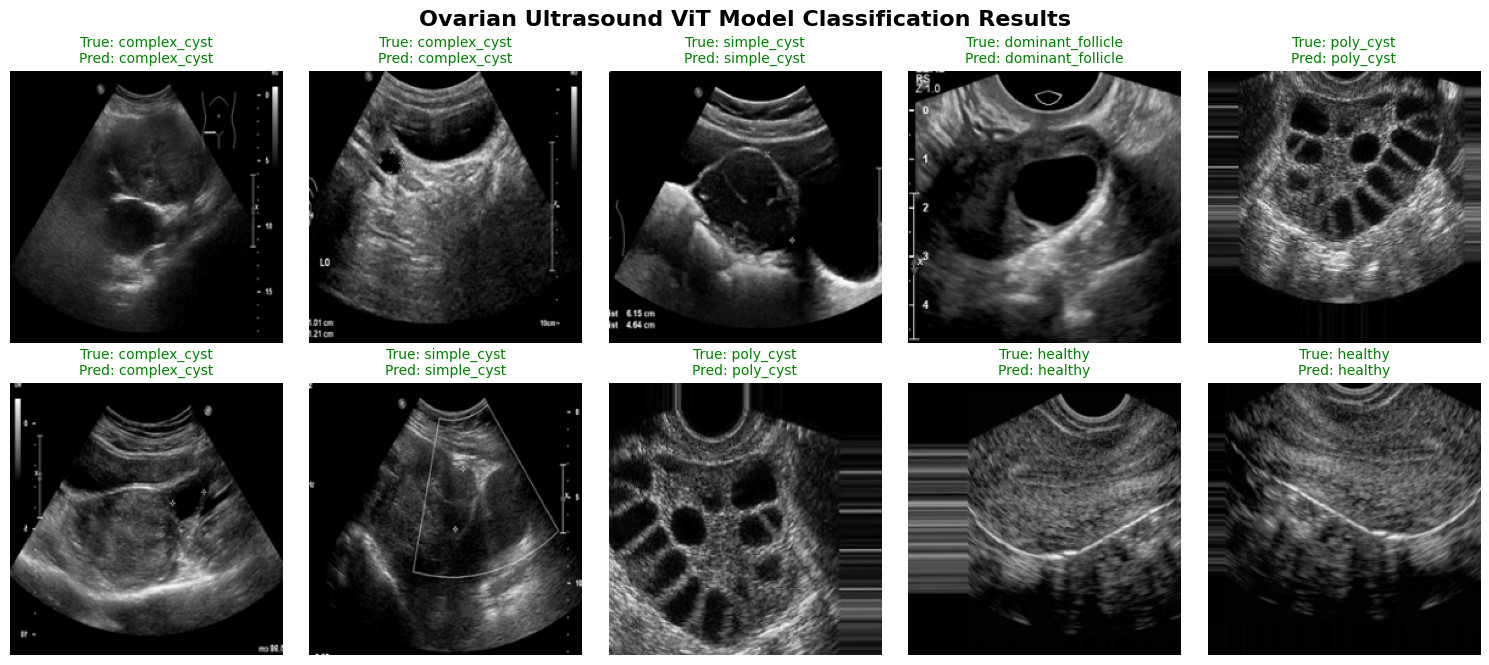

In [ ]:
#--------------------------------
# 6- Visual Prediction Examples
#--------------------------------
# We select 10 random images from the test dataset
num_samples    = 10
random_indices = np.random.choice(len(y_test_all), num_samples, replace=False)

fig, axes = plt.subplots(2, 5, figsize=(15, 7))
fig.suptitle("Ovarian Ultrasound ViT Model Classification Results",
             fontsize=16, fontweight="bold")

for i, ax in enumerate(axes.flatten()):
    idx = random_indices[i]

    # Retrieve the 224x224 grayscale image for visualization
    image_2d = X[idx_test[idx]]

    # Map numerical labels back to string categories
    true_label = CATEGORIES[int(y_test_all[idx])]
    pred_label = CATEGORIES[int(y_pred_vit[idx])]

    # Display the image in grayscale
    ax.imshow(image_2d, cmap="gray")
    ax.axis("off")

    # Set title color (Green = correct, Red = incorrect)
    color = "green" if true_label == pred_label else "red"
    ax.set_title(f"True: {true_label}\nPred: {pred_label}", color=color, fontsize=10)

plt.tight_layout()
plt.subplots_adjust(top=0.9, bottom=0.05, hspace=0.1, wspace=0.1)
plt.show()

In [ ]:
#######################
# Comparative Analysis
#######################

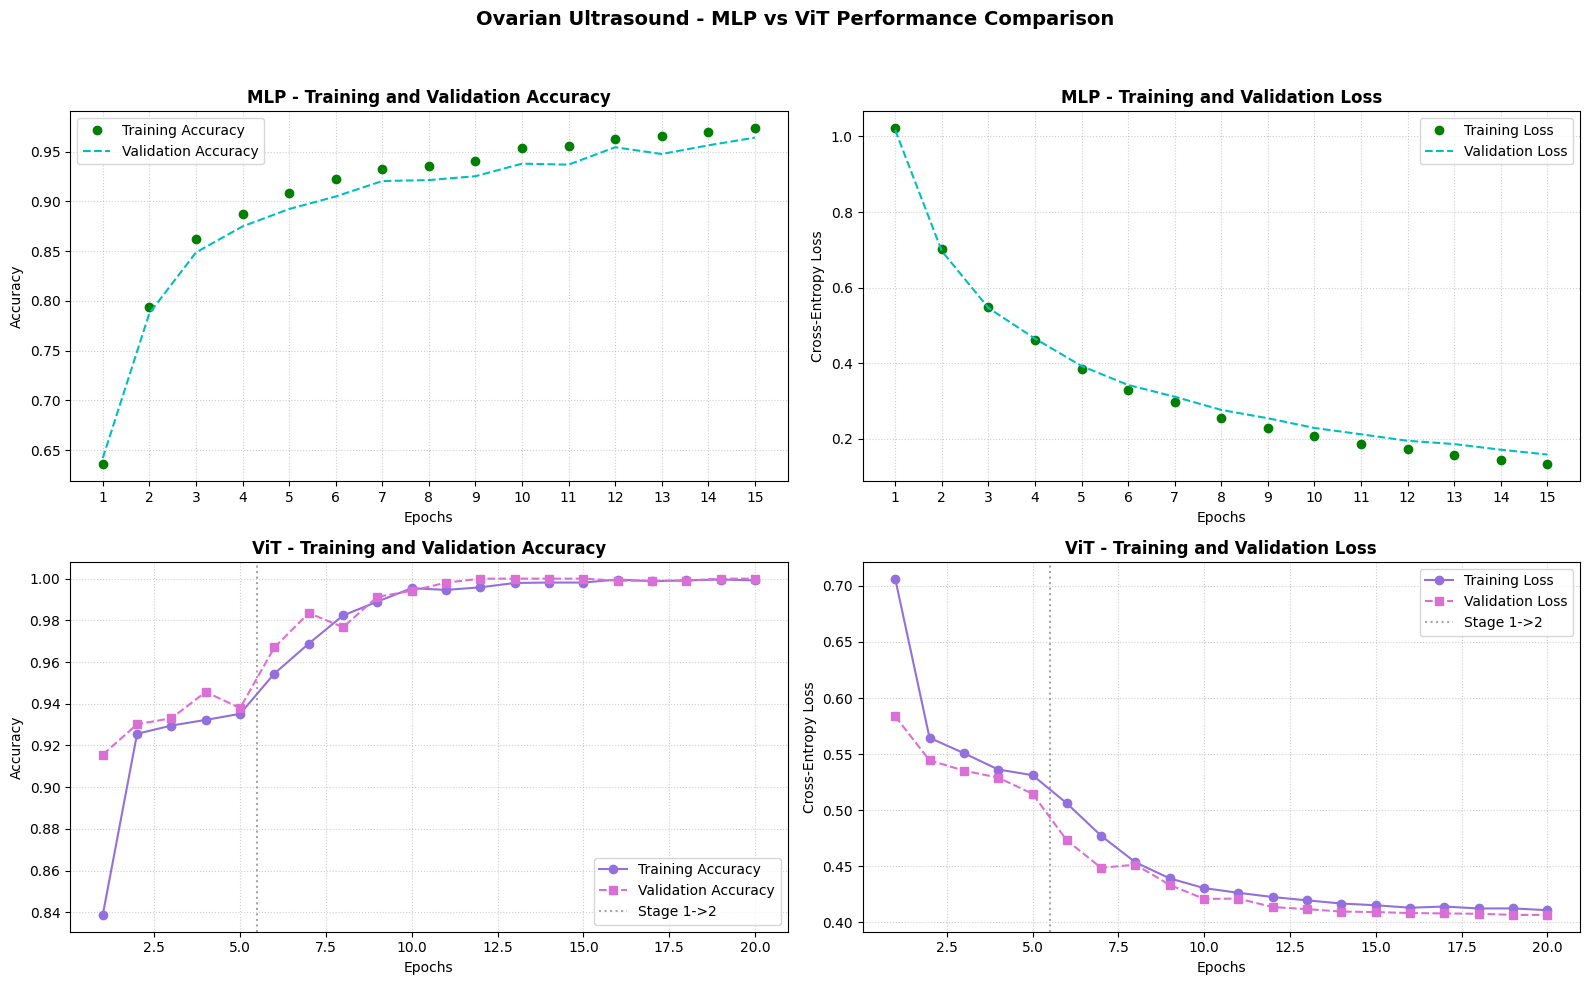

In [ ]:
#-------------------------------------------------
# a) Comparative Training and Validation Metrics
#-------------------------------------------------
fig, axes = plt.subplots(2, 2, figsize=(16, 10))
plt.suptitle("Ovarian Ultrasound - MLP vs ViT Performance Comparison",
             fontsize=14, fontweight="bold")

ep_mlp = range(1, len(model.history["acc"]) + 1)
ep_vit = range(1, len(vit_history["train_acc"]) + 1)

# A. MLP Accuracy (top-left)
ax = axes[0, 0]
ax.plot(ep_mlp, model.history["acc"],     "go",  label="Training Accuracy")
ax.plot(ep_mlp, model.history["val_acc"], "c--", label="Validation Accuracy")
ax.set_title("MLP - Training and Validation Accuracy", fontweight="bold")
ax.set_xlabel("Epochs"); ax.set_ylabel("Accuracy")
ax.set_xticks(list(ep_mlp)); ax.legend()
ax.grid(True, linestyle=":", alpha=0.6)

# B. MLP Loss (top-right)
ax = axes[0, 1]
ax.plot(ep_mlp, model.history["loss"],     "go",  label="Training Loss")
ax.plot(ep_mlp, model.history["val_loss"], "c--", label="Validation Loss")
ax.set_title("MLP - Training and Validation Loss", fontweight="bold")
ax.set_xlabel("Epochs"); ax.set_ylabel("Cross-Entropy Loss")
ax.set_xticks(list(ep_mlp)); ax.legend()
ax.grid(True, linestyle=":", alpha=0.6)

# C. ViT Accuracy (bottom-left)
ax = axes[1, 0]
ax.plot(ep_vit, vit_history["train_acc"], color="mediumpurple", marker="o",
        label="Training Accuracy")
ax.plot(ep_vit, vit_history["val_acc"],   color="orchid", linestyle="--", marker="s",
        label="Validation Accuracy")
ax.axvline(x=5.5, color="gray", linestyle=":", lw=1.5, alpha=0.7, label="Stage 1->2")
ax.set_title("ViT - Training and Validation Accuracy", fontweight="bold")
ax.set_xlabel("Epochs"); ax.set_ylabel("Accuracy")
ax.legend(); ax.grid(True, linestyle=":", alpha=0.6)

# D. ViT Loss (bottom-right)
ax = axes[1, 1]
ax.plot(ep_vit, vit_history["train_loss"], color="mediumpurple", marker="o",
        label="Training Loss")
ax.plot(ep_vit, vit_history["val_loss"],   color="orchid", linestyle="--", marker="s",
        label="Validation Loss")
ax.axvline(x=5.5, color="gray", linestyle=":", lw=1.5, alpha=0.7, label="Stage 1->2")
ax.set_title("ViT - Training and Validation Loss", fontweight="bold")
ax.set_xlabel("Epochs"); ax.set_ylabel("Cross-Entropy Loss")
ax.legend(); ax.grid(True, linestyle=":", alpha=0.6)

plt.tight_layout(rect=[0, 0, 1, 0.95]); plt.show()

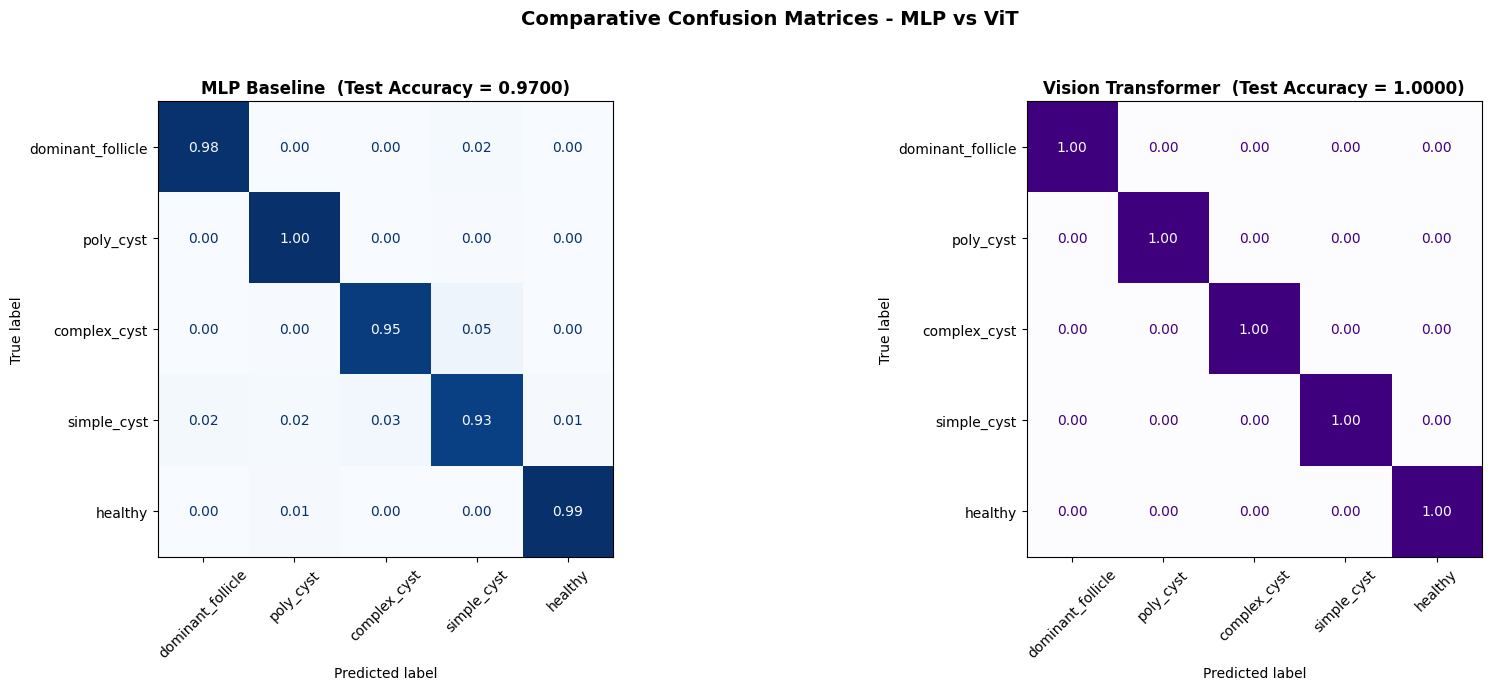

In [ ]:
#------------------------------------
# b) Comparative Confusion Matrices
#------------------------------------
mlp_test_acc = float(np.mean(y_pred      == y_test_all))
vit_test_acc = float(np.mean(y_pred_vit  == y_test_all))

cm_mlp      = confusion_matrix(y_test_all, y_pred)
cm_mlp_norm = cm_mlp.astype(float) / cm_mlp.sum(axis=1, keepdims=True)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(18, 7))
plt.suptitle("Comparative Confusion Matrices - MLP vs ViT",
             fontsize=14, fontweight="bold")

ConfusionMatrixDisplay(cm_mlp_norm, display_labels=CATEGORIES).plot(
    ax=ax1, cmap=plt.cm.Blues, colorbar=False, values_format=".2f")
ax1.set_title(f"MLP Baseline  (Test Accuracy = {mlp_test_acc:.4f})",
              fontsize=12, fontweight="bold")
ax1.tick_params(axis="x", rotation=45)

ConfusionMatrixDisplay(cm_vit_norm, display_labels=CATEGORIES).plot(
    ax=ax2, cmap=plt.cm.Purples, colorbar=False, values_format=".2f")
ax2.set_title(f"Vision Transformer  (Test Accuracy = {vit_test_acc:.4f})",
              fontsize=12, fontweight="bold")
ax2.tick_params(axis="x", rotation=45)

plt.tight_layout(rect=[0, 0, 1, 0.95]); plt.show()

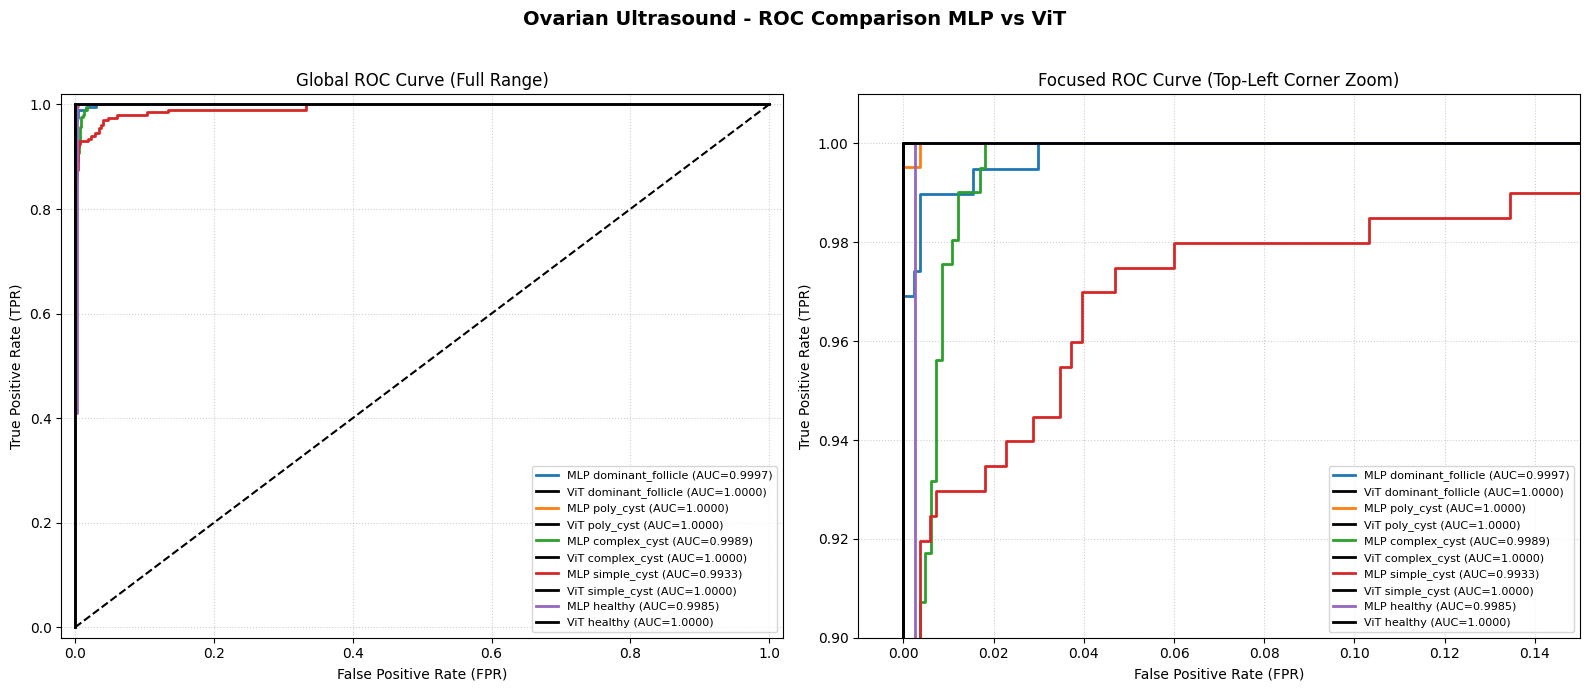

In [ ]:
#------------------------------------------------
# c) Comparative ROC Curve and AUC (Multiclass)
#------------------------------------------------
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
plt.suptitle("Ovarian Ultrasound - ROC Comparison MLP vs ViT",
             fontsize=14, fontweight="bold")

# Use default matplotlib color cycle for MLP (same as cell 12)
mlp_colors = plt.rcParams["axes.prop_cycle"].by_key()["color"]

for i in range(len(CATEGORIES)):
    fpr_m, tpr_m, _ = roc_curve(y_test_bin[:, i], y_score[:, i])
    fpr_v, tpr_v, _ = roc_curve(y_test_bin[:, i], y_score_vit[:, i])
    mlp_color = mlp_colors[i % len(mlp_colors)]

    lbl_mlp = f"MLP {CATEGORIES[i]} (AUC={mlp_auc_scores[CATEGORIES[i]]:.4f})"
    lbl_vit = f"ViT {CATEGORIES[i]} (AUC={vit_auc_scores[CATEGORIES[i]]:.4f})"

    ax1.plot(fpr_m, tpr_m, color=mlp_color, lw=2, label=lbl_mlp)
    ax1.plot(fpr_v, tpr_v, color="black",   lw=2, label=lbl_vit)
    ax2.plot(fpr_m, tpr_m, color=mlp_color, lw=2, label=lbl_mlp)
    ax2.plot(fpr_v, tpr_v, color="black",   lw=2, label=lbl_vit)

for ax in (ax1, ax2):
    ax.plot([0, 1], [0, 1], color="black", lw=1.5, linestyle="--")
    ax.set_xlabel("False Positive Rate (FPR)")
    ax.set_ylabel("True Positive Rate (TPR)")
    ax.legend(loc="lower right", fontsize=8)
    ax.grid(True, linestyle=":", alpha=0.6)

ax1.set_title("Global ROC Curve (Full Range)")
ax1.set_xlim([-0.02, 1.02]); ax1.set_ylim([-0.02, 1.02])

ax2.set_title("Focused ROC Curve (Top-Left Corner Zoom)")
ax2.set_xlim([-0.01, 0.15]); ax2.set_ylim([0.90, 1.01])

plt.tight_layout()
plt.subplots_adjust(top=0.86)
plt.show()

In [ ]:
#---------------------------
# d) Summary Metrics Table
#---------------------------
import pandas as pd

def build_metrics_df(y_true, y_pred_arr, y_score_arr, categories):
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_true, y_pred_arr, labels=list(range(len(categories))))
    y_bin    = label_binarize(y_true, classes=list(range(len(categories))))
    rows, auc_vals = [], []
    for i, cat in enumerate(categories):
        fpr_, tpr_, _ = roc_curve(y_bin[:, i], y_score_arr[:, i])
        auc_val = auc(fpr_, tpr_); auc_vals.append(auc_val)
        rows.append({"Class": cat, "Precision": round(prec[i], 4),
                     "Recall": round(rec[i], 4), "F1-Score": round(f1[i], 4),
                     "AUC": round(auc_val, 4)})
    rows.append({"Class": "MACRO AVG",
                 "Precision": round(float(prec.mean()), 4),
                 "Recall":    round(float(rec.mean()),  4),
                 "F1-Score":  round(float(f1.mean()),   4),
                 "AUC":       round(float(np.mean(auc_vals)), 4)})
    acc = float(np.mean(np.array(y_pred_arr) == np.array(y_true)))
    rows.append({"Class": "ACCURACY", "Precision": "-",
                 "Recall": "-", "F1-Score": "-", "AUC": round(acc, 4)})
    return pd.DataFrame(rows)

df_mlp = build_metrics_df(y_test_all, y_pred,     y_score,     CATEGORIES)
df_vit = build_metrics_df(y_test_all, y_pred_vit, y_score_vit, CATEGORIES)

print("=" * 55)
print("         MLP Baseline - Test Set Metrics")
print("=" * 55)
print(df_mlp.to_string(index=False))
print()
print("=" * 55)
print("       Vision Transformer - Test Set Metrics")
print("=" * 55)
print(df_vit.to_string(index=False))

delta = vit_test_acc - mlp_test_acc
sign  = "+" if delta >= 0 else ""
print(f"\nMLP  Test Accuracy  : {mlp_test_acc:.4f}")
print(f"ViT  Test Accuracy  : {vit_test_acc:.4f}")
print(f"Delta (ViT - MLP)   : {sign}{delta:.4f}")

         MLP Baseline - Test Set Metrics
            Class Precision  Recall F1-Score    AUC
dominant_follicle    0.9795  0.9845    0.982 0.9997
        poly_cyst    0.9726  0.9953   0.9838 1.0000
     complex_cyst    0.9749  0.9463   0.9604 0.9989
      simple_cyst    0.9296  0.9296   0.9296 0.9933
          healthy    0.9909  0.9909   0.9909 0.9985
        MACRO AVG    0.9695  0.9694   0.9694 0.9981
         ACCURACY         -       -        - 0.9700

       Vision Transformer - Test Set Metrics
            Class Precision Recall F1-Score  AUC
dominant_follicle       1.0    1.0      1.0  1.0
        poly_cyst       1.0    1.0      1.0  1.0
     complex_cyst       1.0    1.0      1.0  1.0
      simple_cyst       1.0    1.0      1.0  1.0
          healthy       1.0    1.0      1.0  1.0
        MACRO AVG       1.0    1.0      1.0  1.0
         ACCURACY         -      -        -  1.0

MLP  Test Accuracy  : 0.9700
ViT  Test Accuracy  : 1.0000
Delta (ViT - MLP)   : +0.0300
